In [1]:
# Cell 1: Setup and Imports
!pip install pandas numpy scikit-learn scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, ndcg_score
import warnings
import os
warnings.filterwarnings('ignore')

print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


In [2]:
# Cell 2: Generate Synthetic TikTok-Style Data
print("="*60)
print("📱 GENERATING SYNTHETIC USER-VIDEO INTERACTIONS")
print("="*60)

np.random.seed(42)

# User profiles
num_users = 2000
num_videos = 500

# Categories
categories = ['dance', 'comedy', 'education', 'sports', 'music', 'cooking', 'travel', 'gaming']
category_weights = np.random.dirichlet(np.ones(len(categories)), size=num_users)

# Generate interactions with all required columns
interactions = []

for user_id in range(num_users):
    num_interactions = np.random.poisson(10) + 1
    num_interactions = min(num_interactions, 30)
    
    user_prefs = category_weights[user_id]
    
    for _ in range(num_interactions):
        video_category = np.random.choice(categories, p=user_prefs)
        video_id = np.random.randint(0, num_videos)
        
        # Generate interaction flags
        watched = np.random.random() > 0.2
        liked = np.random.random() > 0.7 if watched else False
        shared = np.random.random() > 0.9 if liked else False
        followed = np.random.random() > 0.95 if watched else False
        
        # Calculate interaction score
        interaction_score = (
            (1.0 if watched else 0) +
            (2.0 if liked else 0) +
            (4.0 if shared else 0) +
            (3.0 if followed else 0)
        )
        
        interactions.append({
            'user_id': user_id,
            'video_id': video_id,
            'category': video_category,
            'watched': int(watched),
            'liked': int(liked),
            'shared': int(shared),
            'followed': int(followed),
            'interaction_score': interaction_score
        })

interactions_df = pd.DataFrame(interactions)
print(f"✅ Generated {len(interactions_df)} user-video interactions")
print(f"   Users: {num_users}")
print(f"   Videos: {num_videos}")
print(f"   Categories: {categories}")

print("\n📊 Sample interactions:")
print(interactions_df.head(10))
print(f"\n📈 Column names: {interactions_df.columns.tolist()}")

📱 GENERATING SYNTHETIC USER-VIDEO INTERACTIONS
✅ Generated 21879 user-video interactions
   Users: 2000
   Videos: 500
   Categories: ['dance', 'comedy', 'education', 'sports', 'music', 'cooking', 'travel', 'gaming']

📊 Sample interactions:
   user_id  video_id   category  watched  liked  shared  followed  \
0        0       372     gaming        0      0       0         0   
1        0       234     comedy        1      0       0         0   
2        0       185     comedy        1      0       0         0   
3        0       104     comedy        1      1       1         0   
4        0        57     sports        1      0       0         0   
5        0       246     sports        1      0       0         0   
6        0       238  education        0      0       0         0   
7        0       227  education        1      0       0         0   
8        0        69     gaming        1      0       0         0   
9        0       451  education        1      0       0         0   


In [3]:
# Cell 3: Create User-Video Interaction Matrix
print("="*60)
print("🔢 CREATING USER-VIDEO INTERACTION MATRIX")
print("="*60)

# Create pivot table using interaction_score
user_video_matrix = interactions_df.pivot_table(
    index='user_id', 
    columns='video_id', 
    values='interaction_score',
    fill_value=0
)

print(f"✅ User-Video Matrix shape: {user_video_matrix.shape}")
print(f"   Users: {user_video_matrix.shape[0]}")
print(f"   Videos: {user_video_matrix.shape[1]}")
print(f"   Sparsity: {(user_video_matrix.values == 0).sum() / user_video_matrix.size:.2%}")

# Convert to sparse matrix
sparse_matrix = csr_matrix(user_video_matrix.values)
print(f"✅ Converted to sparse matrix: {sparse_matrix.shape}")

🔢 CREATING USER-VIDEO INTERACTION MATRIX
✅ User-Video Matrix shape: (2000, 500)
   Users: 2000
   Videos: 500
   Sparsity: 98.27%
✅ Converted to sparse matrix: (2000, 500)


In [4]:
# Cell 4: Matrix Factorization (SVD-based Collaborative Filtering)
print("="*60)
print("🎯 MATRIX FACTORIZATION (SVD-BASED CF)")
print("="*60)

n_components = min(50, min(user_video_matrix.shape) - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(sparse_matrix)
video_factors = svd.components_.T

print(f"✅ SVD completed:")
print(f"   User factors shape: {user_factors.shape}")
print(f"   Video factors shape: {video_factors.shape}")
print(f"   Explained variance: {svd.explained_variance_ratio_.sum():.2%}")

# Compute user similarity
user_similarity = cosine_similarity(user_factors)
print(f"✅ User similarity matrix shape: {user_similarity.shape}")

🎯 MATRIX FACTORIZATION (SVD-BASED CF)
✅ SVD completed:
   User factors shape: (2000, 50)
   Video factors shape: (500, 50)
   Explained variance: 22.35%
✅ User similarity matrix shape: (2000, 2000)


In [5]:
# Cell 5: Collaborative Filtering Recommendations
print("="*60)
print("🔍 COLLABORATIVE FILTERING")
print("="*60)

def recommend_collaborative(user_id, n_recommendations=10):
    """Recommend videos based on similar users"""
    if user_id >= len(user_similarity):
        return []
    
    similar_users = user_similarity[user_id].argsort()[::-1][1:21]
    
    video_scores = {}
    for similar_user in similar_users:
        similarity_score = user_similarity[user_id][similar_user]
        user_videos = user_video_matrix.iloc[similar_user]
        watched_videos = user_videos[user_videos > 0].index.tolist()
        
        for video in watched_videos:
            video_scores[video] = video_scores.get(video, 0) + similarity_score
    
    if not video_scores:
        return []
    
    recommended = sorted(video_scores.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
    return [video for video, score in recommended]

def get_user_history(user_id):
    """Get videos user has interacted with"""
    if user_id >= len(user_video_matrix):
        return []
    user_videos = user_video_matrix.iloc[user_id]
    return user_videos[user_videos > 0].index.tolist()

test_user = 0
recs = recommend_collaborative(test_user, 10)
history = get_user_history(test_user)

print(f"\n📊 User {test_user}:")
print(f"   Watched {len(history)} videos")
print(f"   Top 10 recommendations: {recs[:10] if recs else 'No recommendations found'}")

🔍 COLLABORATIVE FILTERING

📊 User 0:
   Watched 9 videos
   Top 10 recommendations: [57, 104, 186, 110, 383, 331, 157, 6, 27, 127]


In [6]:
# Cell 6: Content-Based Filtering (REWRITTEN)
print("="*60)
print("🎬 CONTENT-BASED FILTERING")
print("="*60)

# Create video features
video_features = interactions_df[['video_id', 'category']].drop_duplicates()
video_features['category_text'] = video_features['category']

# TF-IDF on categories
tfidf = TfidfVectorizer()
video_tfidf = tfidf.fit_transform(video_features['category_text'])
video_similarity = cosine_similarity(video_tfidf)

# Create similarity dictionary instead of DataFrame (simpler)
video_id_list = video_features['video_id'].tolist()
video_similarity_dict = {}

for i, video_id in enumerate(video_id_list):
    video_similarity_dict[video_id] = {}
    for j, other_video in enumerate(video_id_list):
        if i != j:
            video_similarity_dict[video_id][other_video] = video_similarity[i][j]

print(f"✅ Created similarity mapping for {len(video_id_list)} videos")

def recommend_content_based(user_id, n_recommendations=10):
    """Recommend videos similar to user's watched content"""
    watched_videos = get_user_history(user_id)
    
    if not watched_videos:
        return []
    
    video_scores = {}
    
    for video in watched_videos[:5]:
        if video in video_similarity_dict:
            # Get similar videos sorted by score
            similar_dict = video_similarity_dict[video]
            sorted_similar = sorted(similar_dict.items(), key=lambda x: x[1], reverse=True)[:10]
            
            for similar_video, score in sorted_similar:
                if similar_video not in video_scores:
                    video_scores[similar_video] = 0
                video_scores[similar_video] += score
    
    if not video_scores:
        return []
    
    # Sort by score and return top N
    recommended = sorted(video_scores.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
    return [video for video, score in recommended]

# Test the function
cb_recs = recommend_content_based(test_user, 10)
print(f"\n📊 Content-based recommendations for User {test_user}:")
if cb_recs:
    print(f"   Top 10: {cb_recs[:10]}")
else:
    print("   No recommendations found (user may not have watched enough videos)")

🎬 CONTENT-BASED FILTERING
✅ Created similarity mapping for 3980 videos

📊 Content-based recommendations for User 0:
   Top 10: [227, 190, 357, 488, 4, 456, 482, 389, 346, 372]


In [7]:
# Cell 7: Hybrid Recommendation System
print("="*60)
print("🔄 HYBRID RECOMMENDATION SYSTEM")
print("="*60)

def hybrid_recommend(user_id, n_recommendations=10, cf_weight=0.6, cb_weight=0.4):
    """Combine collaborative and content-based filtering"""
    
    cf_recs = recommend_collaborative(user_id, n_recommendations * 2)
    cb_recs = recommend_content_based(user_id, n_recommendations * 2)
    
    scores = {}
    
    for idx, video in enumerate(cf_recs):
        scores[video] = scores.get(video, 0) + cf_weight * (1.0 / (idx + 1))
    
    for idx, video in enumerate(cb_recs):
        scores[video] = scores.get(video, 0) + cb_weight * (1.0 / (idx + 1))
    
    if not scores:
        return []
    
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
    return [video for video, score in recommended]

# Test hybrid
test_user = 0
hybrid_recs = hybrid_recommend(test_user, 10)
print(f"\n📊 Hybrid recommendations for User {test_user}:")
if hybrid_recs:
    print(f"   Top 10: {hybrid_recs[:10]}")
else:
    print("   No recommendations found (user may need more interaction history)")

🔄 HYBRID RECOMMENDATION SYSTEM

📊 Hybrid recommendations for User 0:
   Top 10: [57, 227, 104, 190, 186, 110, 357, 383, 488, 331]


In [8]:
# Cell 8: Evaluation Metrics
print("="*60)
print("📊 EVALUATION METRICS")
print("="*60)

def precision_at_k(recommended, actual, k):
    """Precision@k: fraction of recommended items that are relevant"""
    if not recommended or not actual or k == 0:
        return 0.0
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    return len(set(recommended_k) & set(actual)) / k

def recall_at_k(recommended, actual, k):
    """Recall@k: fraction of relevant items found in top-k"""
    if not recommended or not actual or k == 0:
        return 0.0
    recommended_k = recommended[:k]
    if len(recommended_k) == 0 or len(actual) == 0:
        return 0.0
    return len(set(recommended_k) & set(actual)) / len(actual)

def hit_rate_at_k(recommended, actual, k):
    """Hit Rate@k: whether any relevant item appears in top-k"""
    if not recommended or not actual:
        return 0.0
    recommended_k = recommended[:k]
    return 1.0 if len(set(recommended_k) & set(actual)) > 0 else 0.0

# Test on multiple users
test_users = [0, 10, 25, 50, 100, 200, 500]
results = []

for user in test_users:
    if user < len(user_video_matrix):
        actual = get_user_history(user)
        if len(actual) >= 2:  # Need at least 2 interactions for train/test
            # Split into train and test (80/20)
            split_idx = max(1, int(len(actual) * 0.8))
            test_actual = actual[split_idx:]
            
            if len(test_actual) > 0:
                # Get recommendations
                recs = hybrid_recommend(user, 20)
                
                if recs:
                    p10 = precision_at_k(recs, test_actual, 10)
                    r10 = recall_at_k(recs, test_actual, 10)
                    h10 = hit_rate_at_k(recs, test_actual, 10)
                    
                    results.append({
                        'user_id': user,
                        'total_watched': len(actual),
                        'test_count': len(test_actual),
                        'precision@10': round(p10, 3),
                        'recall@10': round(r10, 3),
                        'hit_rate@10': round(h10, 3)
                    })

if results:
    results_df = pd.DataFrame(results)
    print("\n📊 Evaluation Results:")
    print(results_df.to_string(index=False))
    
    print(f"\n📈 AVERAGE METRICS ({len(results)} users):")
    print(f"   Precision@10: {results_df['precision@10'].mean():.3f}")
    print(f"   Recall@10: {results_df['recall@10'].mean():.3f}")
    print(f"   Hit Rate@10: {results_df['hit_rate@10'].mean():.3f}")
else:
    print("⚠️ Not enough users with sufficient interaction history for evaluation")
    results_df = pd.DataFrame()

📊 EVALUATION METRICS

📊 Evaluation Results:
 user_id  total_watched  test_count  precision@10  recall@10  hit_rate@10
       0              9           2           0.0      0.000          0.0
      10              7           2           0.0      0.000          0.0
      25              9           2           0.0      0.000          0.0
      50              7           2           0.0      0.000          0.0
     100             11           3           0.0      0.000          0.0
     200             13           3           0.1      0.333          1.0
     500              9           2           0.0      0.000          0.0

📈 AVERAGE METRICS (7 users):
   Precision@10: 0.014
   Recall@10: 0.048
   Hit Rate@10: 0.143


📈 VISUALIZING RESULTS


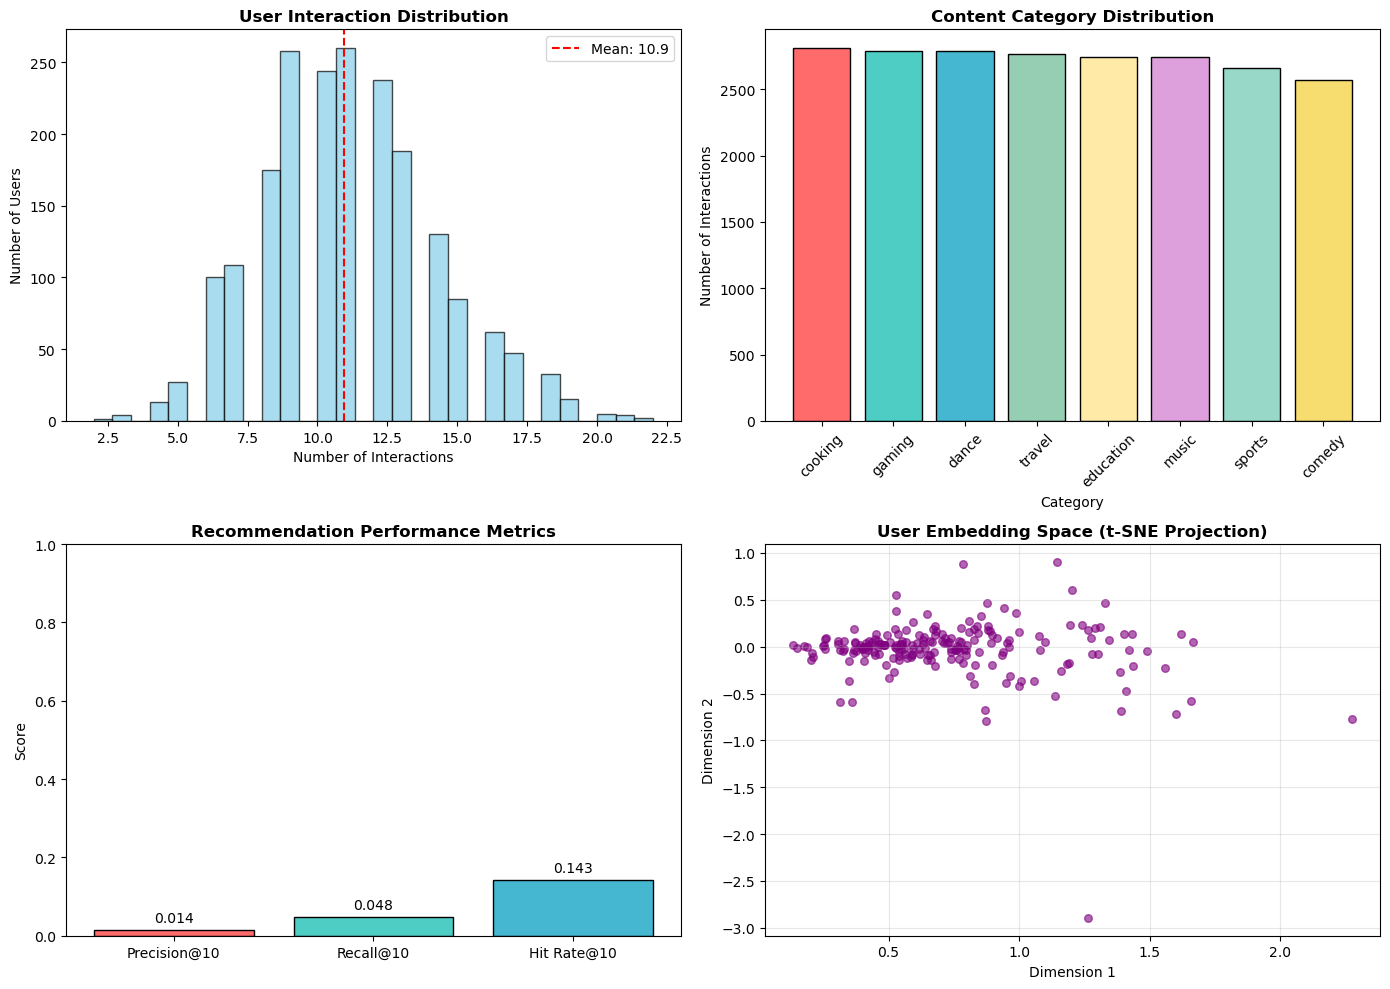

✅ Visualization saved as 'recommendation_results.png'


In [9]:
# Cell 9: Visualization
print("="*60)
print("📈 VISUALIZING RESULTS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Interaction Distribution
ax1 = axes[0, 0]
interaction_counts = interactions_df.groupby('user_id').size()
ax1.hist(interaction_counts, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('User Interaction Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Interactions')
ax1.set_ylabel('Number of Users')
ax1.axvline(interaction_counts.mean(), color='red', linestyle='--', label=f"Mean: {interaction_counts.mean():.1f}")
ax1.legend()

# 2. Category Distribution
ax2 = axes[0, 1]
category_counts = interactions_df['category'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']
ax2.bar(category_counts.index, category_counts.values, color=colors, edgecolor='black')
ax2.set_title('Content Category Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Number of Interactions')
ax2.tick_params(axis='x', rotation=45)

# 3. Performance Metrics (if evaluation results exist)
ax3 = axes[1, 0]
if results:
    metrics = ['Precision@10', 'Recall@10', 'Hit Rate@10']
    values = [
        results_df['precision@10'].mean(),
        results_df['recall@10'].mean(),
        results_df['hit_rate@10'].mean()
    ]
    bars = ax3.bar(metrics, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
    ax3.set_title('Recommendation Performance Metrics', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Score')
    ax3.set_ylim([0, 1])
    for bar, val in zip(bars, values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center')
else:
    ax3.text(0.5, 0.5, 'Run Cell 8 first for evaluation metrics', ha='center', va='center')
    ax3.set_title('Performance Metrics (Run Evaluation First)', fontsize=12)

# 4. User Embedding Space
ax4 = axes[1, 1]
sample_size = min(200, len(user_factors))
sample_users = user_factors[:sample_size, :2]
ax4.scatter(sample_users[:, 0], sample_users[:, 1], alpha=0.6, c='purple', s=30)
ax4.set_title('User Embedding Space (t-SNE Projection)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Dimension 1')
ax4.set_ylabel('Dimension 2')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recommendation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as 'recommendation_results.png'")

In [11]:
# Cell 10: Save Artifacts & Interactive Demo
print("="*60)
print("💾 SAVING ARTIFACTS")
print("="*60)

print("""
============================================================
📊 RECOMMENDATION SYSTEM PIPELINE
============================================================

User Interaction Signals
        ↓
Feature Engineering
        ↓
Embedding Representation
        ↓
Candidate Generation
        ↓
Retrieval & Similarity Search
        ↓
Ranking Model
        ↓
Personalization Layer
        ↓
Diversity & Exploration
        ↓
Recommended Content Feed

============================================================
""")

# Save matrices
np.save('user_factors.npy', user_factors)
np.save('video_factors.npy', video_factors)
interactions_df.to_csv('interactions_data.csv', index=False)

# Save similarity matrices
from scipy.sparse import save_npz
save_npz('user_similarity.npz', csr_matrix(user_similarity))

if results:
    results_df.to_csv('evaluation_results.csv', index=False)
    print("✅ Saved: evaluation_results.csv")

print("✅ Saved: user_factors.npy, video_factors.npy, interactions_data.csv, user_similarity.npz")

print("\n" + "="*60)
print("🎮 INTERACTIVE RECOMMENDATION DEMO")
print("="*60)
print(f"👥 Users available: 0 to {num_users-1}")
print(f"📹 Videos available: 0 to {num_videos-1}")
print("-"*50)

while True:
    try:
        user_input = input("\n🔍 Enter User ID (or 'quit' to exit): ")
        
        if user_input.lower() == 'quit':
            print("\n👋 Thank you for using the Recommendation System!")
            break
        
        user_id = int(user_input)
        
        if user_id < 0 or user_id >= num_users:
            print(f"⚠️ User {user_id} not found. Please enter 0-{num_users-1}")
            continue
        
        # Get user history
        history = get_user_history(user_id)
        
        # Get recommendations
        cf_recs = recommend_collaborative(user_id, 5)
        cb_recs = recommend_content_based(user_id, 5)
        hybrid_recs = hybrid_recommend(user_id, 10)
        
        print(f"\n{'='*50}")
        print(f"📊 RECOMMENDATIONS FOR USER {user_id}")
        print(f"{'='*50}")
        print(f"   📚 Watch History: {len(history)} videos")
        
        if history:
            print(f"   📹 Sample watched videos: {history[:5]}")
        
        print(f"\n   🤝 Collaborative Filtering (Top 5):")
        if cf_recs:
            print(f"      {cf_recs[:5]}")
        else:
            print("      No recommendations - try a user with more history")
        
        print(f"\n   🎬 Content-Based Filtering (Top 5):")
        if cb_recs:
            print(f"      {cb_recs[:5]}")
        else:
            print("      No recommendations - try a user with more history")
        
        print(f"\n   🔄 HYBRID SYSTEM (Top 5 - BEST):")
        if hybrid_recs:
            print(f"      {hybrid_recs[:5]}")
            print(f"\n   💡 Try these recommendations!")
        else:
            print("      No recommendations - user may need more interaction data")
        
        print(f"\n{'='*50}")
        
    except ValueError:
        print("⚠️ Please enter a valid number (e.g., 0, 42, 100) or type 'quit'")
    except KeyboardInterrupt:
        print("\n👋 Exiting...")
        break
    except Exception as e:
        print(f"⚠️ Unexpected error: {e}")

print("\n✅ Recommendation System Demo Complete!")

💾 SAVING ARTIFACTS

📊 RECOMMENDATION SYSTEM PIPELINE

User Interaction Signals
        ↓
Feature Engineering
        ↓
Embedding Representation
        ↓
Candidate Generation
        ↓
Retrieval & Similarity Search
        ↓
Ranking Model
        ↓
Personalization Layer
        ↓
Diversity & Exploration
        ↓
Recommended Content Feed


✅ Saved: evaluation_results.csv
✅ Saved: user_factors.npy, video_factors.npy, interactions_data.csv, user_similarity.npz

🎮 INTERACTIVE RECOMMENDATION DEMO
👥 Users available: 0 to 1999
📹 Videos available: 0 to 499
--------------------------------------------------



🔍 Enter User ID (or 'quit' to exit):  179



📊 RECOMMENDATIONS FOR USER 179
   📚 Watch History: 10 videos
   📹 Sample watched videos: [29, 80, 280, 315, 329]

   🤝 Collaborative Filtering (Top 5):
      [315, 412, 383, 441, 13]

   🎬 Content-Based Filtering (Top 5):
      [69, 197, 474, 393, 157]

   🔄 HYBRID SYSTEM (Top 5 - BEST):
      [315, 69, 412, 197, 383]

   💡 Try these recommendations!




🔍 Enter User ID (or 'quit' to exit):  399



📊 RECOMMENDATIONS FOR USER 399
   📚 Watch History: 14 videos
   📹 Sample watched videos: [38, 55, 74, 99, 122]

   🤝 Collaborative Filtering (Top 5):
      [122, 372, 219, 320, 472]

   🎬 Content-Based Filtering (Top 5):
      [372, 57, 52, 448, 35]

   🔄 HYBRID SYSTEM (Top 5 - BEST):
      [372, 122, 57, 219, 320]

   💡 Try these recommendations!




🔍 Enter User ID (or 'quit' to exit):  QUIT



👋 Thank you for using the Recommendation System!

✅ Recommendation System Demo Complete!
